###Importar bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

###Dados

In [2]:
df = pd.read_excel('BaseCaseChurnPorto.xlsx')
df.head()

,CAT_ESTADO_CIVIL,CAT_GENERO,MESES_RELAC_PRODUTO,QTD_PRODUTOS_ATIVOS,IDADE,FLAG_CHURN
0,SOLTEIRO,M,186,2,37.0,0
1,NaN,NaN,66,1,NaN,0
2,CASADO,M,97,3,70.0,0
3,NaN,NaN,54,2,NaN,0
4,CASADO,M,4,1,63.0,0


In [3]:
df['CAT_ESTADO_CIVIL'].value_counts()

,count
CAT_ESTADO_CIVIL,
CASADO,14236
SOLTEIRO,8342
VIUVO,823
DIVORCIADO,804


In [4]:
df['CAT_GENERO'].value_counts()

,count
CAT_GENERO,
M,14238
F,10868
I,27
N,4


In [5]:
df['QTD_PRODUTOS_ATIVOS'].value_counts()

,count
QTD_PRODUTOS_ATIVOS,
1,25852
3,6251
2,5335
4,3195
5,1319
6,516
7,201
8,70
9,31


In [6]:
df['FLAG_CHURN'].value_counts()

,count
FLAG_CHURN,
0,36353
1,6450


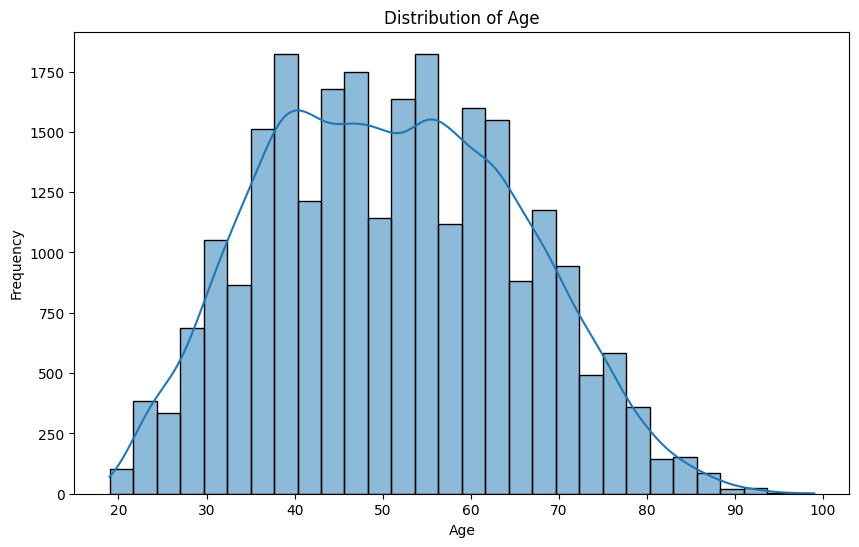

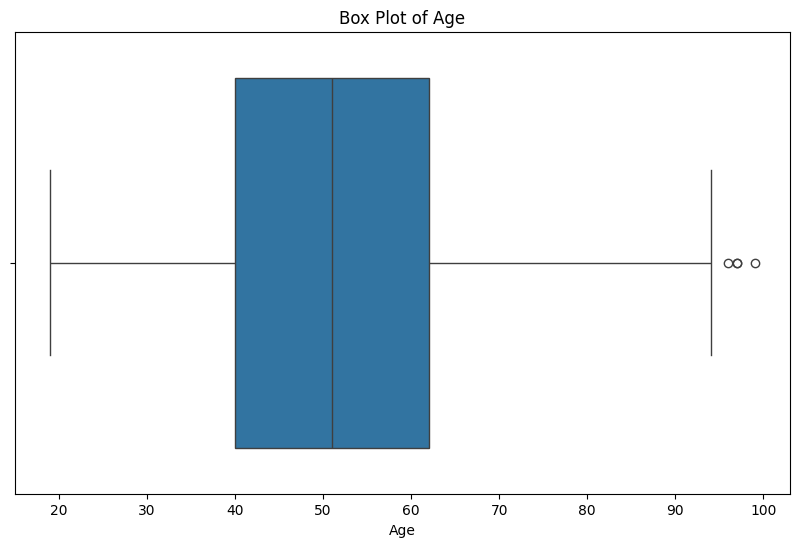

In [7]:
# prompt: gerar grafico da idade

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is already loaded and contains a column named 'IDADE'
# Plotting the distribution of 'IDADE'
plt.figure(figsize=(10, 6))
sns.histplot(df['IDADE'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Optional: Box plot for age distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['IDADE'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

###Pre-processamento

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42803 entries, 0 to 42802
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAT_ESTADO_CIVIL     24205 non-null  object 
 1   CAT_GENERO           25137 non-null  object 
 2   MESES_RELAC_PRODUTO  42803 non-null  int64  
 3   QTD_PRODUTOS_ATIVOS  42803 non-null  int64  
 4   IDADE                25137 non-null  float64
 5   FLAG_CHURN           42803 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.0+ MB


In [9]:
# prompt: contagen de valores nulos

df.isnull().sum()


,0
CAT_ESTADO_CIVIL,18598
CAT_GENERO,17666
MESES_RELAC_PRODUTO,0
QTD_PRODUTOS_ATIVOS,0
IDADE,17666
FLAG_CHURN,0


In [10]:
df_model = df.copy()

In [11]:
# Tratar valores nulos
cat_cols = ["CAT_ESTADO_CIVIL", "CAT_GENERO"]
num_cols = ["IDADE"]

cat_imputer = SimpleImputer(strategy="most_frequent")
num_imputer = SimpleImputer(strategy="mean")

df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])
df_model[num_cols] = num_imputer.fit_transform(df_model[num_cols])

In [12]:
# Codificar variáveis categóricas
le_estado_civil = LabelEncoder()
le_genero = LabelEncoder()
df_model["CAT_ESTADO_CIVIL"] = le_estado_civil.fit_transform(df_model["CAT_ESTADO_CIVIL"])
df_model["CAT_GENERO"] = le_genero.fit_transform(df_model["CAT_GENERO"])

In [13]:
# Separar variáveis preditoras e alvo
X = df_model.drop("FLAG_CHURN", axis=1)
y = df_model["FLAG_CHURN"]

In [14]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42803 entries, 0 to 42802
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAT_ESTADO_CIVIL     42803 non-null  int64  
 1   CAT_GENERO           42803 non-null  int64  
 2   MESES_RELAC_PRODUTO  42803 non-null  int64  
 3   QTD_PRODUTOS_ATIVOS  42803 non-null  int64  
 4   IDADE                42803 non-null  float64
 5   FLAG_CHURN           42803 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 2.0 MB


In [24]:
df_model['CAT_GENERO'].value_counts()

,count
CAT_GENERO,
2,31904
0,10868
1,27
3,4


In [15]:
# prompt: remover dados duplicados

df_model.drop_duplicates(inplace=True)

In [16]:
# prompt: igualara quantidade os dados para FLAG_CHURN igual a 0 e 1

from sklearn.utils import resample

# Separar as classes
df_majority = df_model[df_model.FLAG_CHURN==0]
df_minority = df_model[df_model.FLAG_CHURN==1]

# Downsample da classe majoritária
df_majority_downsampled = resample(df_majority,
                                  replace=False,    # sample without replacement
                                  n_samples=len(df_minority), # to match minority class size
                                  random_state=123) # for reproducible results

# Concatenar a classe minoritária com a majoritária downsampled
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Exibir a contagem das classes no novo dataframe balanceado
print(df_balanced['FLAG_CHURN'].value_counts())

# Atualizar X e y com o dataframe balanceado
X = df_balanced.drop("FLAG_CHURN", axis=1)
y = df_balanced["FLAG_CHURN"]


FLAG_CHURN
0    3370
1    3370
Name: count, dtype: int64


###Dividir em treino e teste

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Cópia do dataframe original
df_model = df.copy()

# Imputação de valores ausentes
cat_imputer = SimpleImputer(strategy="most_frequent")
num_imputer = SimpleImputer(strategy="mean")

# Colunas categóricas
cat_cols = ["CAT_ESTADO_CIVIL", "CAT_GENERO"]
# Colunas numéricas
num_cols = ["IDADE"]

# Imputação
df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])
df_model[num_cols] = num_imputer.fit_transform(df_model[num_cols])

# Codificação de variáveis categóricas
le_estado_civil = LabelEncoder()
le_genero = LabelEncoder()
df_model["CAT_ESTADO_CIVIL"] = le_estado_civil.fit_transform(df_model["CAT_ESTADO_CIVIL"])
df_model["CAT_GENERO"] = le_genero.fit_transform(df_model["CAT_GENERO"])

# Separar features e target
X = df_model.drop("FLAG_CHURN", axis=1)
y = df_model["FLAG_CHURN"]

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Avaliação
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=False)

report

'              precision    recall  f1-score   support\n\n           0       0.91      0.95      0.93      7230\n           1       0.63      0.50      0.56      1331\n\n    accuracy                           0.88      8561\n   macro avg       0.77      0.73      0.75      8561\nweighted avg       0.87      0.88      0.87      8561\n'

In [19]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7230
           1       0.63      0.50      0.56      1331

    accuracy                           0.88      8561
   macro avg       0.77      0.73      0.75      8561
weighted avg       0.87      0.88      0.87      8561



              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7230
           1       0.63      0.50      0.56      1331

    accuracy                           0.88      8561
   macro avg       0.77      0.73      0.75      8561
weighted avg       0.87      0.88      0.87      8561



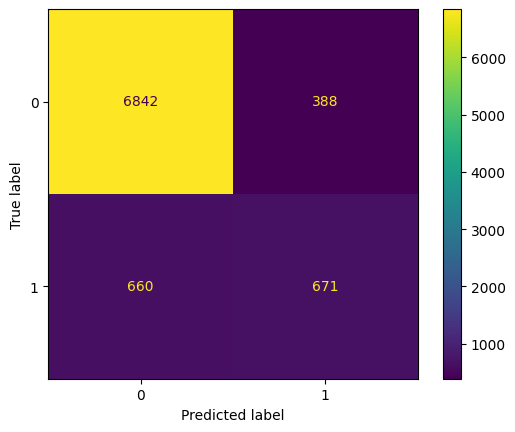

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7230
           1       0.57      0.58      0.57      1331

    accuracy                           0.87      8561
   macro avg       0.74      0.75      0.75      8561
weighted avg       0.87      0.87      0.87      8561

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7230
           1       0.57      0.58      0.57      1331

    accuracy                           0.87      8561
   macro avg       0.74      0.75      0.75      8561
weighted avg       0.87      0.87      0.87      8561



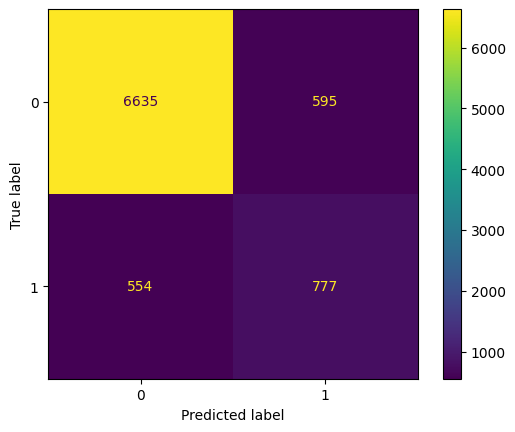

In [21]:
# prompt: aumentar o peso do churn igual a 1

# Treinar modelo Random Forest com peso maior para a classe 1 (churn)
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Avaliação
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=False)

report
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


Relatório de Classificação com pesos ajustados para a classe 0:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7230
           1       0.59      0.57      0.58      1331

    accuracy                           0.87      8561
   macro avg       0.75      0.75      0.75      8561
weighted avg       0.87      0.87      0.87      8561



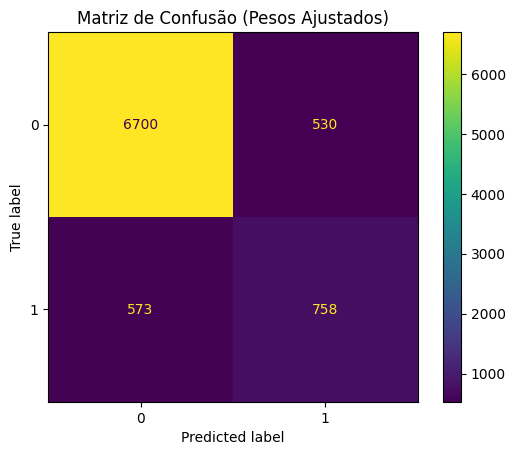

In [22]:
# prompt: aumentar o peso para o FLAG_CHURN igual a 0

# Aumentar o peso para a classe 0 (não-churn)
# Calcular os pesos das classes manualmente
class_weights = {0: 1, 1: 3}  # Aumentando o peso para a classe 0

# Treinar modelo Random Forest com pesos de classe definidos manualmente
model_weighted = RandomForestClassifier(random_state=42, class_weight=class_weights)
model_weighted.fit(X_train, y_train)

# Avaliação do modelo com pesos ajustados
y_pred_weighted = model_weighted.predict(X_test)

print("\nRelatório de Classificação com pesos ajustados para a classe 0:")
print(classification_report(y_test, y_pred_weighted))

# Matriz de Confusão para o modelo com pesos ajustados
cm_weighted = confusion_matrix(y_test, y_pred_weighted, labels=model_weighted.classes_)
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=model_weighted.classes_)
disp_weighted.plot()
plt.title('Matriz de Confusão (Pesos Ajustados)')
plt.show()

Equilibrar a quantidade de dado de churn 0 e 1 para treninamento e test

Distribuição das classes após oversampling:
FLAG_CHURN
0    29123
1    29123
Name: count, dtype: int64

Relatório de Classificação após oversampling:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      7230
           1       0.52      0.62      0.57      1331

    accuracy                           0.85      8561
   macro avg       0.73      0.76      0.74      8561
weighted avg       0.86      0.85      0.86      8561



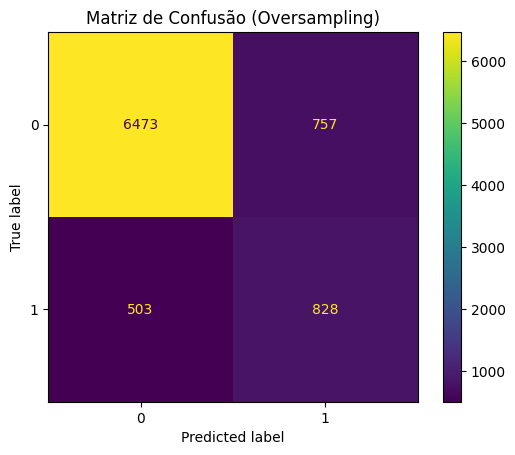

In [23]:
# prompt: balancear com oversampling dados e treinar o modelo novamente


from imblearn.over_sampling import RandomOverSampler

# Instanciar o RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Aplicar o oversampling aos dados de treino
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Verificar a distribuição das classes nos dados reamostrados
print("Distribuição das classes após oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Treinar o modelo Random Forest novamente com os dados reamostrados
model_resampled = RandomForestClassifier(random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Avaliação do modelo treinado com oversampling
y_pred_resampled = model_resampled.predict(X_test)

print("\nRelatório de Classificação após oversampling:")
print(classification_report(y_test, y_pred_resampled))

# Matriz de Confusão para o modelo treinado com oversampling
cm_resampled = confusion_matrix(y_test, y_pred_resampled, labels=model_resampled.classes_)
disp_resampled = ConfusionMatrixDisplay(confusion_matrix=cm_resampled, display_labels=model_resampled.classes_)
disp_resampled.plot()
plt.title('Matriz de Confusão (Oversampling)')
plt.show()